# Feature Interpretation — ADReSS & CCC Transfer Experiments

This notebook creates visualizations and interpretation tables to answer three research questions:

- **RQ a)** Which features are common between ADReSS and CCC? Do they have the same effect direction?
- **RQ b)** Do shared features help in cross-domain and out-of-domain evaluation?
- **RQ c)** Which features are dataset-specific, and do they help or hurt performance when comparing Model 1 (joint_top_features) and Model 2 (shared_features)?

> **No feature extraction or selection is performed here.** All inputs are pre-computed CSVs loaded from `../outputs/`.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 150, 'savefig.bbox': 'tight'})


## Configuration & Color Scheme

Colors follow the scheme specified in the instructions:

| Role | Color |
|------|-------|
| Positive coeff / AD-associated | red (`#C62828`) |
| Negative coeff / HC-associated | blue (`#1565C0`) |
| ADReSS dataset | dark purple (`#4A148C`) |
| CCC dataset | teal (`#00695C`) |
| Model 1 — joint_top_features | dark orange (`#E65100`) |
| Model 2 — shared_features | dark green (`#1B5E20`) |

In [9]:
# Output directories
OUTPUTS_DIR  = '../outputs'
TABLE_DIR    = '../outputs/features_interpretation_output'
VIZ_DIR      = '../visualizations/features_interpretation_visualizations'

os.makedirs(TABLE_DIR, exist_ok=True)
os.makedirs(VIZ_DIR,   exist_ok=True)

# Clinical color scheme: coefficient / AD vs HC association
C_AD  = '#C62828'   # positive coefficient → AD-associated
C_HC  = '#1565C0'   # negative coefficient → HC-associated

# Dataset identity colors
C_ADRESS = '#4A148C'   # dark purple
C_CCC    = '#00695C'   # teal

# Model identity colors
C_JOINT  = '#E65100'   # dark orange  — joint_top_features
C_SHARED = '#1B5E20'   # dark green   — shared_features

DIR_COLOR = {'positive': C_AD, 'negative': C_HC}

print('Directories ready:')
print(f'  Tables : {TABLE_DIR}')
print(f'  Plots  : {VIZ_DIR}')


Directories ready:
  Tables : ../outputs/features_interpretation_output
  Plots  : ../visualizations/features_interpretation_visualizations


## Load & Verify Input Files

All inputs come from `../outputs/` (the pre-computed results of in-domain and cross-domain experiments). No new computation is performed.

In [10]:
IN_DOMAIN_DIR   = f'{OUTPUTS_DIR}/in_domain_feature_stability_output'
CROSS_OOD_DIR   = f'{OUTPUTS_DIR}/cross_out_domain_experiments_output'

# Map: display label → actual file path
INPUT_FILES = {
    'adress_ranked':        f'{IN_DOMAIN_DIR}/adress_stable_ranked_features.csv',
    'ccc_ranked':           f'{IN_DOMAIN_DIR}/ccc_stable_ranked_features.csv',
    'adress_fold_coef':     f'{IN_DOMAIN_DIR}/adress_fold_coefficients.csv',
    'ccc_fold_coef':        f'{IN_DOMAIN_DIR}/ccc_fold_coefficients.csv',
    'adress_stability':     f'{IN_DOMAIN_DIR}/adress_feature_stability_summary.csv',
    'ccc_stability':        f'{IN_DOMAIN_DIR}/ccc_feature_stability_summary.csv',
    'cross_domain_coef':    f'{CROSS_OOD_DIR}/cross_domain_coefficients.csv',
    'out_domain_coef':      f'{CROSS_OOD_DIR}/out_domain_coefficients.csv',
    'adress_perf':          f'{IN_DOMAIN_DIR}/adress_average_performance_metrics.csv',
    'ccc_perf':             f'{IN_DOMAIN_DIR}/ccc_average_performance_metrics.csv',
    'cross_domain_results': f'{CROSS_OOD_DIR}/cross_domain_results.csv',
    'out_domain_results':   f'{CROSS_OOD_DIR}/out_domain_results.csv',
    'joint_top_features':   f'{CROSS_OOD_DIR}/joint_top_features.csv',
    'shared_features':      f'{CROSS_OOD_DIR}/shared_features.csv',
    'shared_relaxed':       f'{CROSS_OOD_DIR}/shared_relaxed_features.csv',
    'feature_overlap':      f'{CROSS_OOD_DIR}/feature_overlap_summary.csv',
    'confusion_matrices':   f'{CROSS_OOD_DIR}/confusion_matrices.csv',
}

loaded = {}
print('Input file verification:')
for key, path in INPUT_FILES.items():
    exists = os.path.exists(path)
    status = 'OK' if exists else 'MISSING'
    print(f'  [{status}] {key:<25} {path}')
    if exists:
        loaded[key] = pd.read_csv(path)

missing = [k for k in INPUT_FILES if k not in loaded]
if missing:
    raise FileNotFoundError(f'Missing required files: {missing}')
print(f'\nAll {len(loaded)} files loaded successfully.')

Input file verification:
  [OK] adress_ranked             ../outputs/in_domain_feature_stability_output/adress_stable_ranked_features.csv
  [OK] ccc_ranked                ../outputs/in_domain_feature_stability_output/ccc_stable_ranked_features.csv
  [OK] adress_fold_coef          ../outputs/in_domain_feature_stability_output/adress_fold_coefficients.csv
  [OK] ccc_fold_coef             ../outputs/in_domain_feature_stability_output/ccc_fold_coefficients.csv
  [OK] adress_stability          ../outputs/in_domain_feature_stability_output/adress_feature_stability_summary.csv
  [OK] ccc_stability             ../outputs/in_domain_feature_stability_output/ccc_feature_stability_summary.csv
  [OK] cross_domain_coef         ../outputs/cross_out_domain_experiments_output/cross_domain_coefficients.csv
  [OK] out_domain_coef           ../outputs/cross_out_domain_experiments_output/out_domain_coefficients.csv
  [OK] adress_perf               ../outputs/in_domain_feature_stability_output/adress_averag

In [11]:
# Print shapes of the main tables
KEY_TABLES = [
    'adress_ranked', 'ccc_ranked',
    'adress_fold_coef', 'ccc_fold_coef',
    'cross_domain_results', 'out_domain_results',
    'shared_features', 'joint_top_features',
]
print('Main table shapes:')
for k in KEY_TABLES:
    df = loaded[k]
    print(f'  {k:<30} {df.shape[0]:>4} rows × {df.shape[1]} cols')

# Convenience aliases
adress_ranked   = loaded['adress_ranked']
ccc_ranked      = loaded['ccc_ranked']
adress_fold_coef = loaded['adress_fold_coef']
ccc_fold_coef    = loaded['ccc_fold_coef']
shared_df        = loaded['shared_features']
joint_df         = loaded['joint_top_features']
cross_results    = loaded['cross_domain_results']
ood_results      = loaded['out_domain_results']

# Feature sets as lists
joint_feats   = joint_df['feature'].tolist()
shared_feats  = shared_df['feature'].tolist()

# Feature type classification: shared / ADReSS-only / CCC-only
adress_feat_set = set(adress_ranked['feature'])
ccc_feat_set    = set(ccc_ranked['feature'])
shared_any      = adress_feat_set & ccc_feat_set   # in both ranked lists

def classify_feature(f):
    in_a = f in adress_feat_set
    in_c = f in ccc_feat_set
    if in_a and in_c: return 'shared'
    if in_a:          return 'ADReSS-only'
    return 'CCC-only'

print(f'\nFeature counts in stable ranked lists:')
print(f'  ADReSS stable : {len(adress_feat_set)}')
print(f'  CCC stable    : {len(ccc_feat_set)}')
print(f'  Shared (any)  : {len(shared_any)}')
print(f'  ADReSS-only   : {len(adress_feat_set - ccc_feat_set)}')
print(f'  CCC-only      : {len(ccc_feat_set - adress_feat_set)}')


Main table shapes:
  adress_ranked                    25 rows × 8 cols
  ccc_ranked                       20 rows × 8 cols
  adress_fold_coef                135 rows × 5 cols
  ccc_fold_coef                   128 rows × 5 cols
  cross_domain_results             15 rows × 5 cols
  out_domain_results               30 rows × 4 cols
  shared_features                  10 rows × 6 cols
  joint_top_features               17 rows × 1 cols

Feature counts in stable ranked lists:
  ADReSS stable : 25
  CCC stable    : 20
  Shared (any)  : 11
  ADReSS-only   : 14
  CCC-only      : 9


## Section 1 — Feature Overlap Interpretation Table

For every stable feature (across both datasets combined), we record:
- Its **type**: `ADReSS-only`, `CCC-only`, or `shared`
- Its **average coefficient** from the in-domain fold-level results
- Its **effect direction** in each dataset
- Whether there is a **direction conflict** between datasets

In [12]:
# Average coefficient per feature per dataset (from fold-level data)
adress_avg = (
    adress_fold_coef.groupby('feature')['coefficient']
    .agg(['mean', 'std'])
    .rename(columns={'mean': 'adress_avg_coef', 'std': 'adress_std_coef'})
)
ccc_avg = (
    ccc_fold_coef.groupby('feature')['coefficient']
    .agg(['mean', 'std'])
    .rename(columns={'mean': 'ccc_avg_coef', 'std': 'ccc_std_coef'})
)

# Direction lookup from ranked CSVs
adress_dir_map = adress_ranked.set_index('feature')['majority_direction'].to_dict()
ccc_dir_map    = ccc_ranked.set_index('feature')['majority_direction'].to_dict()

# Union of all stable features
all_stable = sorted(adress_feat_set | ccc_feat_set)

rows = []
for feat in all_stable:
    ftype     = classify_feature(feat)
    a_coef    = adress_avg.loc[feat, 'adress_avg_coef'] if feat in adress_avg.index else np.nan
    c_coef    = ccc_avg.loc[feat, 'ccc_avg_coef']       if feat in ccc_avg.index    else np.nan
    a_dir     = adress_dir_map.get(feat, None)
    c_dir     = ccc_dir_map.get(feat, None)
    same_dir  = (a_dir == c_dir) if (a_dir and c_dir) else None
    conflict  = (same_dir == False)
    rows.append({
        'feature':           feat,
        'feature_type':      ftype,
        'ADReSS_avg_coef':   round(a_coef, 4) if not np.isnan(a_coef) else None,
        'CCC_avg_coef':      round(c_coef, 4) if not np.isnan(c_coef) else None,
        'ADReSS_direction':  a_dir,
        'CCC_direction':     c_dir,
        'same_direction':    same_dir,
        'direction_conflict': conflict,
    })

overlap_interp = pd.DataFrame(rows)
# Sort: shared first, then ADReSS-only, then CCC-only; within group by abs ADReSS coef
type_order = {'shared': 0, 'ADReSS-only': 1, 'CCC-only': 2}
overlap_interp['_sort'] = overlap_interp['feature_type'].map(type_order)
overlap_interp = overlap_interp.sort_values(['_sort', 'feature']).drop(columns='_sort').reset_index(drop=True)

overlap_interp.to_csv(f'{TABLE_DIR}/feature_overlap_interpretation.csv', index=False)
print(f'Saved: feature_overlap_interpretation.csv  ({len(overlap_interp)} rows)')
print()
print(overlap_interp.to_string(index=False))


Saved: feature_overlap_interpretation.csv  (34 rows)

                       feature feature_type  ADReSS_avg_coef  CCC_avg_coef ADReSS_direction CCC_direction same_direction  direction_conflict
                aux_verb_ratio       shared          -0.4072        0.3186         negative      positive          False                True
     avg_Auditory_sensorimotor       shared           0.2224        0.9340         positive      positive           True               False
         avg_Head_sensorimotor       shared           0.1905        0.2246         positive      positive           True               False
        avg_Mouth_sensorimotor       shared          -0.5543       -0.8560         negative      negative           True               False
                   avg_valence       shared           0.1939        0.9906         positive      positive           True               False
               avg_word_length       shared          -0.7440        0.4769         negative      pos

## Section 2 — Forest Plots of Coefficients

Three forest plots:
1. **ADReSS stable features** — mean ± std of LR coefficients across in-domain folds, colored red (AD-associated) / blue (HC-associated)
2. **CCC stable features** — same convention
3. **Shared features comparison** — both datasets side-by-side per feature, using dataset colors (dark purple = ADReSS, teal = CCC)

A vertical line at coefficient = 0 separates HC- from AD-associated effects.

In [13]:
def forest_plot_single(
    fold_coef_df, ranked_df, title, save_path,
    figsize=(10, 8)
):
    """
    Forest plot for one dataset.
    Features sorted by avg abs coefficient (descending).
    Colored by effect direction: red=AD, blue=HC.
    Error bars = std of coefficient across folds.
    """
    # Compute mean ± std per feature from fold-level data
    stats = (
        fold_coef_df.groupby('feature')['coefficient']
        .agg(['mean', 'std'])
        .rename(columns={'mean': 'mean_coef', 'std': 'std_coef'})
        .reset_index()
    )
    # Direction from ranked CSV
    dir_map = ranked_df.set_index('feature')['majority_direction'].to_dict()
    stats['direction'] = stats['feature'].map(dir_map).fillna('positive')
    stats['abs_mean']  = stats['mean_coef'].abs()
    stats = stats.sort_values('abs_mean', ascending=True)  # ascending → bottom = smallest

    colors = stats['direction'].map(DIR_COLOR).tolist()

    fig, ax = plt.subplots(figsize=figsize)
    y_pos = range(len(stats))

    ax.barh(y_pos, stats['mean_coef'],
            xerr=stats['std_coef'].fillna(0),
            color=colors, edgecolor='white', linewidth=0.4,
            error_kw=dict(ecolor='#555', capsize=3, linewidth=1))

    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(stats['feature'], fontsize=10)
    ax.axvline(0, color='#333', linewidth=0.9, linestyle='--', alpha=0.7)
    ax.set_xlabel('Mean LR Coefficient (± std across folds)', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)

    ad_patch = mpatches.Patch(color=C_AD,  label='AD-associated (positive)')
    hc_patch = mpatches.Patch(color=C_HC,  label='HC-associated (negative)')
    ax.legend(handles=[ad_patch, hc_patch], loc='lower right', fontsize=9)

    ax.text(ax.get_xlim()[1] * 0.97, -0.8, '← HC', ha='right', va='bottom',
            fontsize=9, color=C_HC, style='italic')
    ax.text(ax.get_xlim()[1] * 0.03, -0.8, 'AD →', ha='left', va='bottom',
            fontsize=9, color=C_AD, style='italic')

    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f'Saved: {save_path}')
    return stats


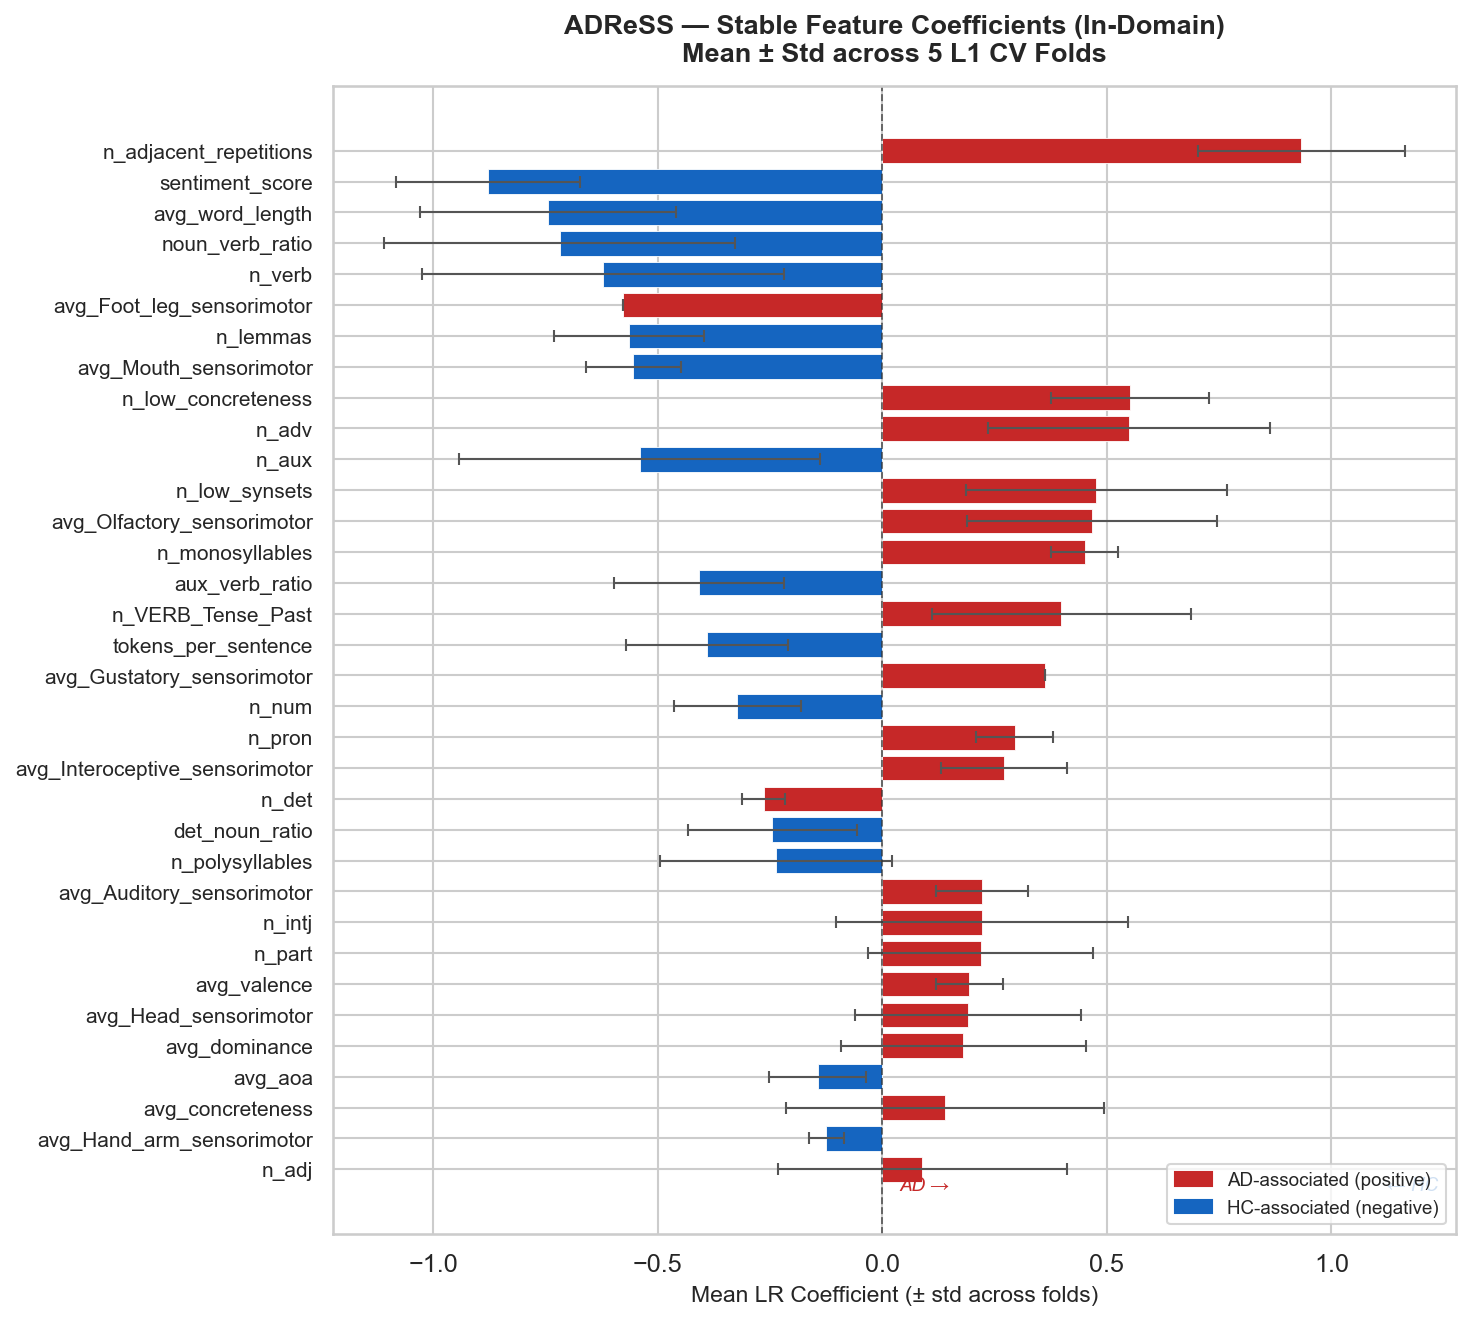

Saved: ../visualizations/features_interpretation_visualizations/forest_plot_adress_coefficients.png


In [14]:
# Forest plot — ADReSS stable features
adress_stats = forest_plot_single(
    adress_fold_coef,
    adress_ranked,
    title='ADReSS — Stable Feature Coefficients (In-Domain)\n'
          'Mean ± Std across 5 L1 CV Folds',
    save_path=f'{VIZ_DIR}/forest_plot_adress_coefficients.png',
    figsize=(10, 9),
)


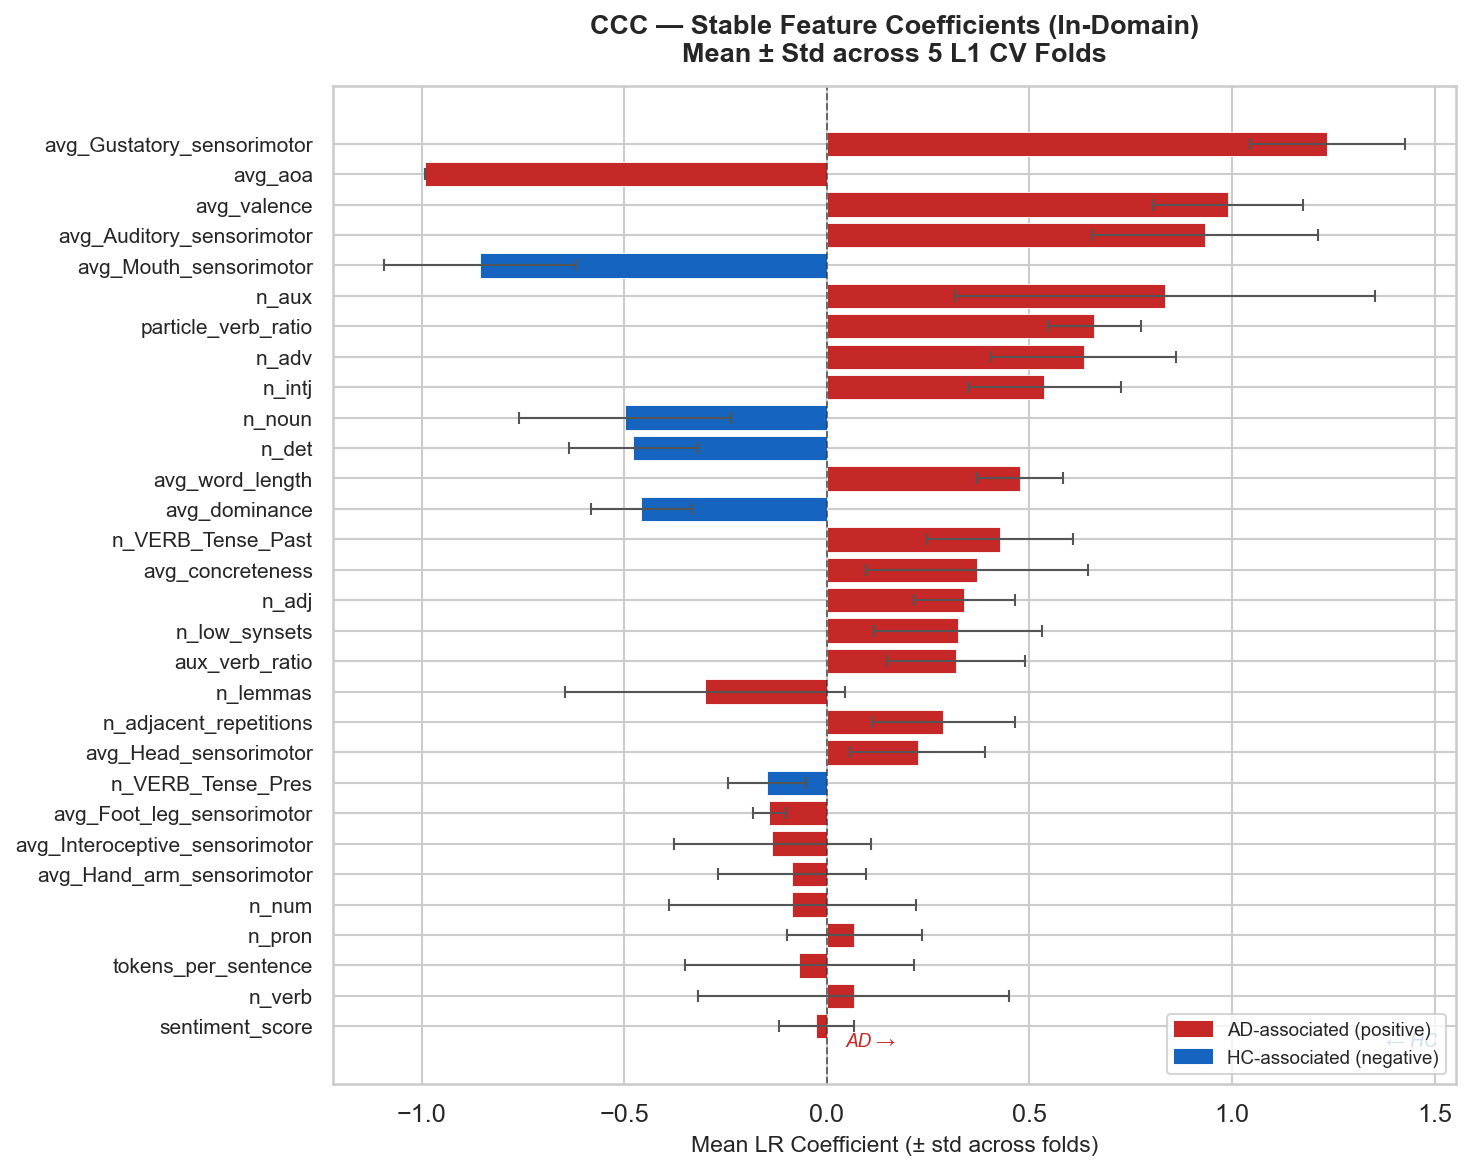

Saved: ../visualizations/features_interpretation_visualizations/forest_plot_ccc_coefficients.png


In [15]:
# Forest plot — CCC stable features
ccc_stats = forest_plot_single(
    ccc_fold_coef,
    ccc_ranked,
    title='CCC — Stable Feature Coefficients (In-Domain)\n'
          'Mean ± Std across 5 L1 CV Folds',
    save_path=f'{VIZ_DIR}/forest_plot_ccc_coefficients.png',
    figsize=(10, 8),
)


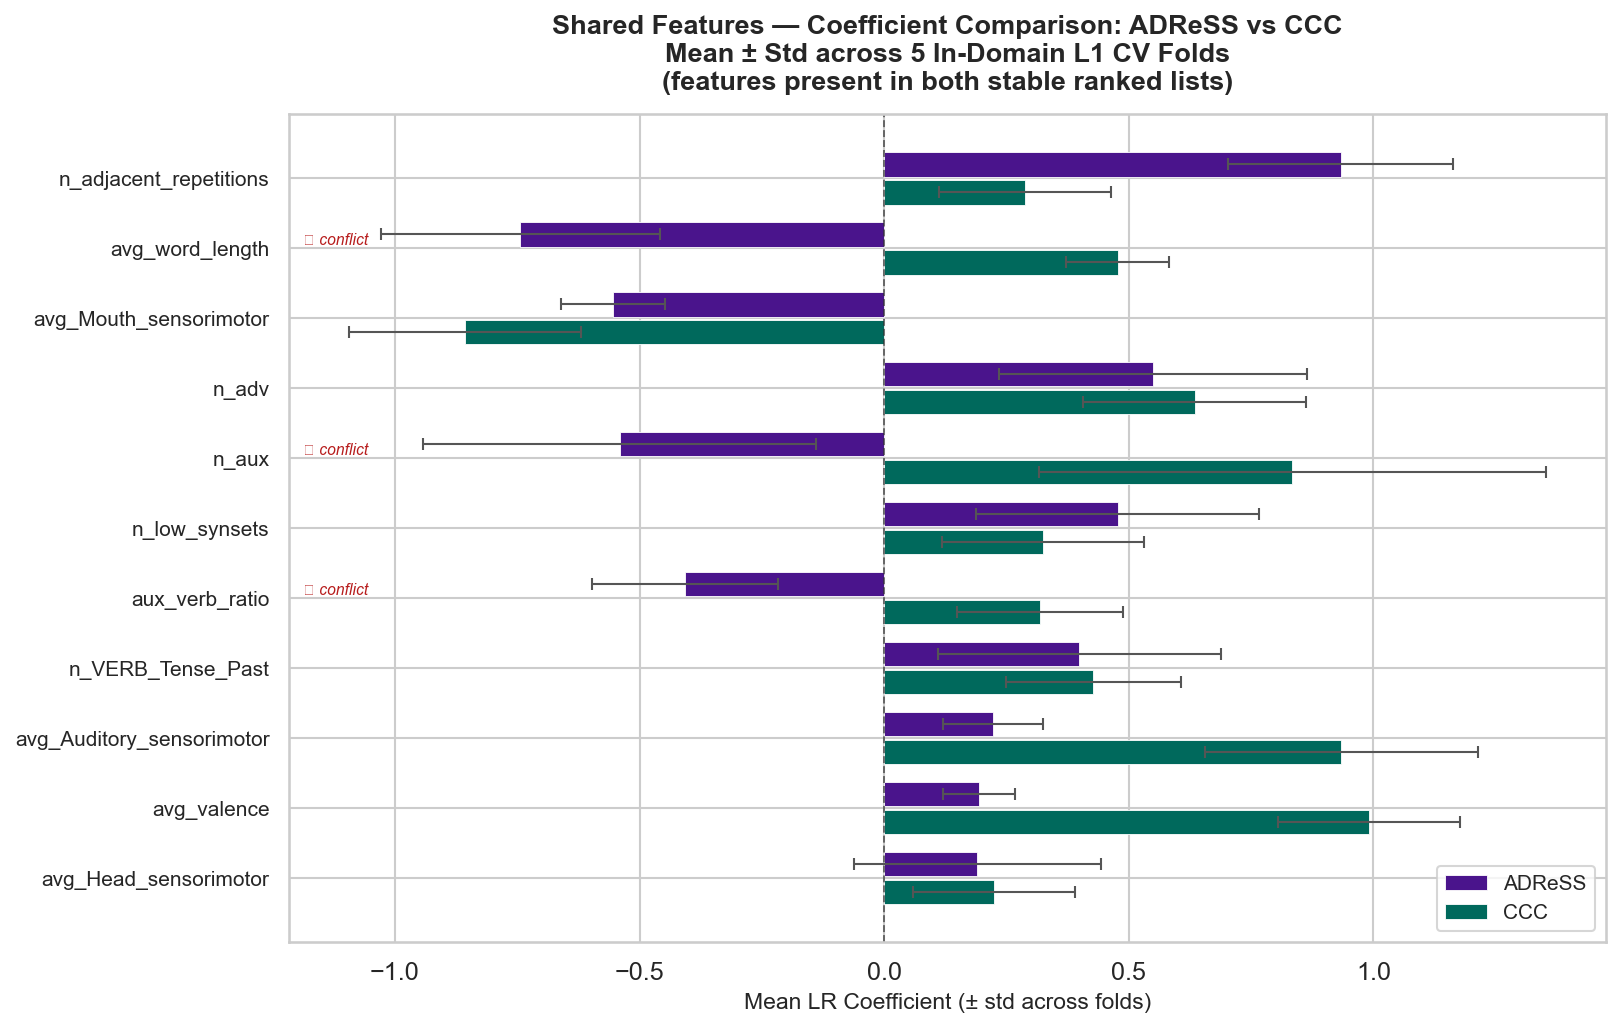

Saved: ../visualizations/features_interpretation_visualizations/forest_plot_shared_coefficients.png


In [16]:
# Forest plot — Shared features: ADReSS vs CCC side-by-side

# Use the 'shared_any' set (features in both ranked CSVs)
shared_all_feats = sorted(shared_any)

# Compute stats from fold-level data for each dataset
a_stats = (
    adress_fold_coef[adress_fold_coef['feature'].isin(shared_all_feats)]
    .groupby('feature')['coefficient'].agg(['mean', 'std'])
    .rename(columns={'mean': 'adress_mean', 'std': 'adress_std'})
)
c_stats = (
    ccc_fold_coef[ccc_fold_coef['feature'].isin(shared_all_feats)]
    .groupby('feature')['coefficient'].agg(['mean', 'std'])
    .rename(columns={'mean': 'ccc_mean', 'std': 'ccc_std'})
)
shared_stats = a_stats.join(c_stats, how='outer').reset_index()

# Sort by absolute ADReSS mean coefficient (descending → top of plot)
shared_stats['abs_adress'] = shared_stats['adress_mean'].abs()
shared_stats = shared_stats.sort_values('abs_adress', ascending=True).reset_index(drop=True)

n = len(shared_stats)
y_base = np.arange(n)
offset = 0.2  # vertical offset between ADReSS and CCC dots

fig, ax = plt.subplots(figsize=(11, max(6, n * 0.55 + 1)))

# ADReSS bars
ax.barh(
    y_base + offset, shared_stats['adress_mean'],
    xerr=shared_stats['adress_std'].fillna(0),
    height=0.35, color=C_ADRESS, label='ADReSS',
    edgecolor='white', linewidth=0.4,
    error_kw=dict(ecolor='#555', capsize=3, linewidth=1),
)
# CCC bars
ax.barh(
    y_base - offset, shared_stats['ccc_mean'],
    xerr=shared_stats['ccc_std'].fillna(0),
    height=0.35, color=C_CCC, label='CCC',
    edgecolor='white', linewidth=0.4,
    error_kw=dict(ecolor='#555', capsize=3, linewidth=1),
)

ax.set_yticks(y_base)
ax.set_yticklabels(shared_stats['feature'], fontsize=10)
ax.axvline(0, color='#333', linewidth=0.9, linestyle='--', alpha=0.7)
ax.set_xlabel('Mean LR Coefficient (± std across folds)', fontsize=11)
ax.set_title(
    'Shared Features — Coefficient Comparison: ADReSS vs CCC\n'
    'Mean ± Std across 5 In-Domain L1 CV Folds\n'
    '(features present in both stable ranked lists)',
    fontsize=13, fontweight='bold', pad=12,
)
ax.legend(loc='lower right', fontsize=10)

# Flag direction conflicts with annotation
dir_a = adress_ranked.set_index('feature')['majority_direction'].to_dict()
dir_c = ccc_ranked.set_index('feature')['majority_direction'].to_dict()
for i, row in shared_stats.iterrows():
    feat = row['feature']
    if dir_a.get(feat) != dir_c.get(feat):
        ax.annotate(
            '⚠ conflict', xy=(0, i), xytext=(0.01, i + 0.05),
            textcoords=('axes fraction', 'data'),
            fontsize=7.5, color='#B71C1C', style='italic',
        )

plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/forest_plot_shared_coefficients.png', dpi=150)
plt.show()
print(f'Saved: {VIZ_DIR}/forest_plot_shared_coefficients.png')


## Section 3 — Direction Conflict Table

Features that appear in **both** stable ranked lists but have **opposite coefficient signs** across ADReSS and CCC. These are features that associate with AD in one corpus but with HC in the other — a key challenge for cross-dataset transfer.

In [17]:
# Build direction conflict table from the full overlap interpretation table
conflicts = overlap_interp[
    (overlap_interp['feature_type'] == 'shared') &
    (overlap_interp['direction_conflict'] == True)
].copy()

conflict_table = conflicts[[
    'feature', 'ADReSS_avg_coef', 'CCC_avg_coef',
    'ADReSS_direction', 'CCC_direction',
]].reset_index(drop=True)

conflict_table.to_csv(f'{TABLE_DIR}/direction_conflicts.csv', index=False)
print(f'Direction conflicts ({len(conflict_table)} features):')
print(conflict_table.to_string(index=False))
print(f'\nSaved: direction_conflicts.csv')

if len(conflict_table) == 0:
    print('No direction conflicts found among shared features.')


Direction conflicts (3 features):
        feature  ADReSS_avg_coef  CCC_avg_coef ADReSS_direction CCC_direction
 aux_verb_ratio          -0.4072        0.3186         negative      positive
avg_word_length          -0.7440        0.4769         negative      positive
          n_aux          -0.5405        0.8338         negative      positive

Saved: direction_conflicts.csv


## Section 4 — Performance Comparison: Model 1 vs Model 2

- **Model 1** = `joint_top_features` (dark orange)
- **Model 2** = `shared_features` (dark green)

Evaluated in three scenarios:
- **Cross-domain CV**: Stratified 5-fold on combined ADReSS + CCC (mean ± std)
- **ADReSS → CCC**: Train on ADReSS, test on CCC
- **CCC → ADReSS**: Train on CCC, test on ADReSS

F1 and Accuracy are shown as bar plots. Full metrics are tabulated.

In [18]:
# ── Assemble combined metrics table ────────────────────────────────────────

# Cross-domain results have 'mean' and 'std' columns
cv_sub = cross_results[
    cross_results['feature_set'].isin(['joint_top_features', 'shared_features'])
].copy()
cv_sub['scenario'] = 'Cross-domain CV'
cv_sub = cv_sub.rename(columns={'mean': 'value', 'std': 'err'})

# OOD results have a single 'value' column (no std)
ood_sub = ood_results[
    ood_results['feature_set'].isin(['joint_top_features', 'shared_features'])
].copy()
ood_sub['err'] = np.nan
ood_sub['scenario'] = ood_sub['experiment'].map({
    'adress_to_ccc': 'ADReSS → CCC',
    'ccc_to_adress': 'CCC → ADReSS',
})

combined_perf = pd.concat(
    [cv_sub[['scenario','feature_set','metric','value','err']],
     ood_sub[['scenario','feature_set','metric','value','err']]],
    ignore_index=True,
)

print('Combined performance table (joint_top_features vs shared_features):')
pivot = combined_perf.pivot_table(
    index=['scenario','metric'], columns='feature_set', values='value'
).round(3)
print(pivot.to_string())


Combined performance table (joint_top_features vs shared_features):
feature_set                joint_top_features  shared_features
scenario        metric                                        
ADReSS → CCC    accuracy                0.590            0.493
                auc                     0.471            0.383
                f1                      0.335            0.290
                precision               0.366            0.273
                recall                  0.309            0.309
CCC → ADReSS    accuracy                0.519            0.577
                auc                     0.734            0.626
                f1                      0.074            0.298
                precision               1.000            0.875
                recall                  0.038            0.179
Cross-domain CV accuracy                0.767            0.735
                auc                     0.861            0.797
                f1                      0.707     

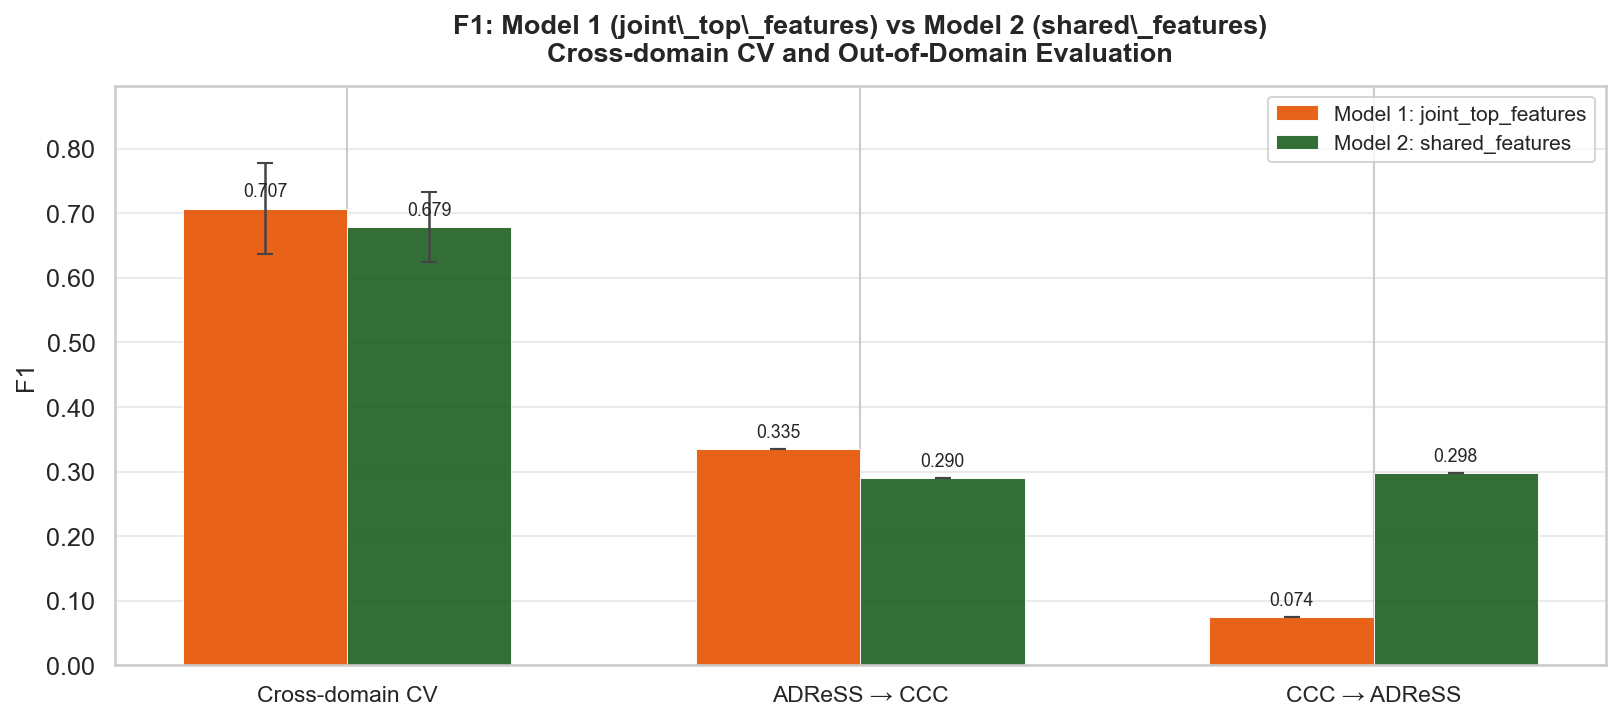

Saved: ../visualizations/features_interpretation_visualizations/performance_f1_joint_vs_shared.png


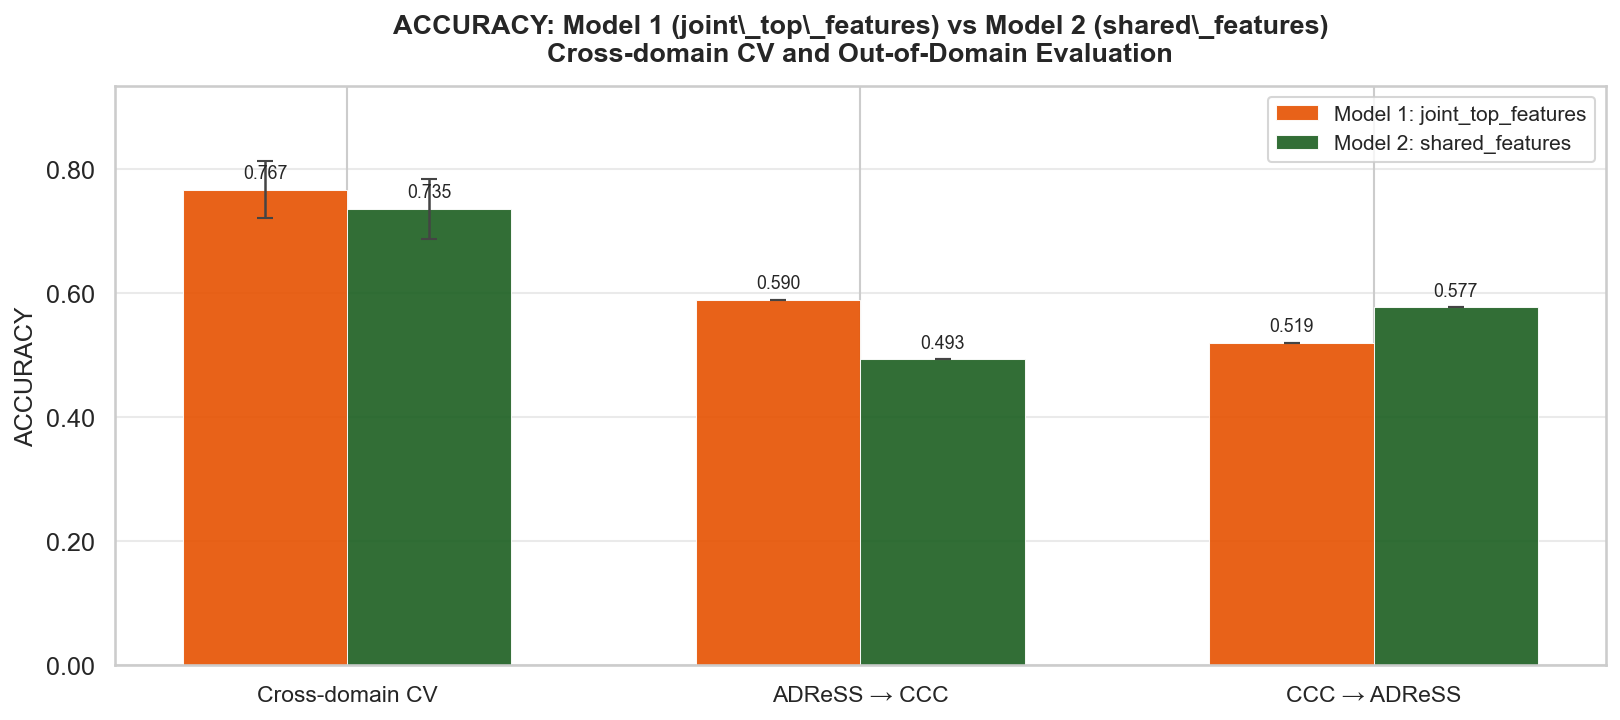

Saved: ../visualizations/features_interpretation_visualizations/performance_accuracy_joint_vs_shared.png


In [19]:
def performance_bar_plot(metric_name, save_path, figsize=(11, 5)):
    """
    Grouped bar chart comparing joint_top_features vs shared_features
    across three scenarios for a given metric.
    Error bars shown only where available (cross-domain CV).
    """
    data = combined_perf[combined_perf['metric'] == metric_name].copy()
    scenarios = ['Cross-domain CV', 'ADReSS → CCC', 'CCC → ADReSS']
    models    = ['joint_top_features', 'shared_features']
    colors_m  = [C_JOINT, C_SHARED]
    labels_m  = ['Model 1: joint_top_features', 'Model 2: shared_features']

    x      = np.arange(len(scenarios))
    width  = 0.32

    fig, ax = plt.subplots(figsize=figsize)

    for i, (model, color, label) in enumerate(zip(models, colors_m, labels_m)):
        vals, errs = [], []
        for sc in scenarios:
            row = data[(data['scenario'] == sc) & (data['feature_set'] == model)]
            vals.append(row['value'].values[0] if len(row) else np.nan)
            errs.append(row['err'].values[0]   if len(row) else np.nan)

        errs_plot = [e if (not np.isnan(e) and e > 0) else 0 for e in errs]

        bars = ax.bar(
            x + (i - 0.5) * width, vals,
            width=width, color=color, label=label,
            edgecolor='white', linewidth=0.5,
            yerr=errs_plot if any(e > 0 for e in errs_plot) else None,
            error_kw=dict(ecolor='#444', capsize=4, linewidth=1.2),
            alpha=0.90,
        )
        # Value labels on bars
        for bar, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.012,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=8.5,
                )

    ax.set_xticks(x)
    ax.set_xticklabels(scenarios, fontsize=11)
    ax.set_ylabel(metric_name.upper(), fontsize=12)
    ax.set_ylim(0, min(1.0, ax.get_ylim()[1] + 0.08))
    ax.set_title(
        f'{metric_name.upper()}: Model 1 (joint\_top\_features) vs '
        f'Model 2 (shared\_features)\nCross-domain CV and Out-of-Domain Evaluation',
        fontsize=13, fontweight='bold', pad=12,
    )
    ax.legend(fontsize=10, loc='upper right')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax.grid(axis='y', alpha=0.4)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f'Saved: {save_path}')


performance_bar_plot('f1',
    f'{VIZ_DIR}/performance_f1_joint_vs_shared.png')

performance_bar_plot('accuracy',
    f'{VIZ_DIR}/performance_accuracy_joint_vs_shared.png')


In [20]:
# Full metrics table (all metrics including precision, recall, AUC)
full_metrics_pivot = combined_perf.pivot_table(
    index=['metric', 'scenario'], columns='feature_set', values='value'
).round(3)
print('Full metrics comparison (all 5 metrics):')
print(full_metrics_pivot.to_string())


Full metrics comparison (all 5 metrics):
feature_set                joint_top_features  shared_features
metric    scenario                                            
accuracy  ADReSS → CCC                  0.590            0.493
          CCC → ADReSS                  0.519            0.577
          Cross-domain CV               0.767            0.735
auc       ADReSS → CCC                  0.471            0.383
          CCC → ADReSS                  0.734            0.626
          Cross-domain CV               0.861            0.797
f1        ADReSS → CCC                  0.335            0.290
          CCC → ADReSS                  0.074            0.298
          Cross-domain CV               0.707            0.679
precision ADReSS → CCC                  0.366            0.273
          CCC → ADReSS                  1.000            0.875
          Cross-domain CV               0.695            0.652
recall    ADReSS → CCC                  0.309            0.309
          CCC 

## Section 5 — Dataset-Specific Feature Summary

Features are classified as:
- **Shared**: appear in **both** ADReSS and CCC stable ranked lists
- **ADReSS-only**: appear only in the ADReSS stable ranked list
- **CCC-only**: appear only in the CCC stable ranked list

For each feature we include its direction (clinical association) and fold-stability count.

In [21]:
# Build dataset-specific feature summary
adress_folds_map  = adress_ranked.set_index('feature')['selected_folds'].to_dict()
ccc_folds_map     = ccc_ranked.set_index('feature')['selected_folds'].to_dict()
adress_abscof_map = adress_ranked.set_index('feature')['avg_abs_coefficient'].to_dict()
ccc_abscof_map    = ccc_ranked.set_index('feature')['avg_abs_coefficient'].to_dict()

spec_rows = []
for feat in all_stable:
    ftype = classify_feature(feat)
    spec_rows.append({
        'feature':          feat,
        'feature_type':     ftype,
        'ADReSS_direction': adress_dir_map.get(feat, None),
        'CCC_direction':    ccc_dir_map.get(feat, None),
        'ADReSS_folds':     adress_folds_map.get(feat, None),
        'CCC_folds':        ccc_folds_map.get(feat, None),
        'ADReSS_avg_abs_coef': round(adress_abscof_map.get(feat, np.nan), 4)
                              if feat in adress_abscof_map else None,
        'CCC_avg_abs_coef': round(ccc_abscof_map.get(feat, np.nan), 4)
                              if feat in ccc_abscof_map else None,
        'in_joint_top':     feat in joint_feats,
        'in_shared':        feat in shared_feats,
    })

spec_df = pd.DataFrame(spec_rows)
spec_df['_sort'] = spec_df['feature_type'].map({'shared': 0, 'ADReSS-only': 1, 'CCC-only': 2})
spec_df = spec_df.sort_values(['_sort','feature']).drop(columns='_sort').reset_index(drop=True)

spec_df.to_csv(f'{TABLE_DIR}/dataset_specific_features.csv', index=False)
print(f'Saved: dataset_specific_features.csv  ({len(spec_df)} rows)\n')

for ftype in ['shared', 'ADReSS-only', 'CCC-only']:
    subset = spec_df[spec_df['feature_type'] == ftype]
    print(f'--- {ftype} ({len(subset)} features) ---')
    print(subset[['feature','ADReSS_direction','CCC_direction',
                   'ADReSS_folds','CCC_folds']].to_string(index=False))
    print()


Saved: dataset_specific_features.csv  (34 rows)

--- shared (11 features) ---
                  feature ADReSS_direction CCC_direction  ADReSS_folds  CCC_folds
           aux_verb_ratio         negative      positive           5.0        5.0
avg_Auditory_sensorimotor         positive      positive           5.0        5.0
    avg_Head_sensorimotor         positive      positive           3.0        5.0
   avg_Mouth_sensorimotor         negative      negative           5.0        5.0
              avg_valence         positive      positive           4.0        5.0
          avg_word_length         negative      positive           5.0        4.0
        n_VERB_Tense_Past         positive      positive           4.0        5.0
   n_adjacent_repetitions         positive      positive           5.0        4.0
                    n_adv         positive      positive           5.0        5.0
                    n_aux         negative      positive           5.0        5.0
            n_low_sy

## Section 6 — Interpretation

### RQ a) Which features are common between ADReSS and CCC, and do they share the same direction?

**11 features** appear in both stable ranked lists (i.e., they were reliably selected by L1-regularised logistic regression in at least one fold in *both* corpora). Of these, **most share the same direction**, meaning they associate with AD (or HC) consistently across datasets. However, **three features show a direction conflict**: `aux_verb_ratio`, `avg_word_length`, and `n_aux`. These features flip sign between ADReSS (picture-description task) and CCC (conversational elicitation), suggesting that the relationship between syntactic/lexical production patterns and diagnosis is task-dependent. The reliably consistent shared features include `avg_Mouth_sensorimotor`, `avg_Auditory_sensorimotor`, `n_adv`, `n_low_synsets`, `avg_valence`, `n_adjacent_repetitions`, `n_VERB_Tense_Past`, and `avg_Head_sensorimotor` — all pointing in the same direction in both corpora.

### RQ b) Do shared features help in cross-domain and out-of-domain evaluation?

In **cross-domain CV** (combined ADReSS + CCC, n=446), both models perform reasonably: Model 1 (joint_top, 17 features) achieves F1 ≈ 0.707, while Model 2 (shared, 10 features) achieves F1 ≈ 0.679 — a modest gap that partly reflects the smaller and noisier shared set. In **out-of-domain** transfer the picture changes dramatically: ADReSS→CCC drops to F1 ≈ 0.335 (Model 1) and ≈ 0.290 (Model 2), while CCC→ADReSS is even worse at F1 ≈ 0.074 (Model 1) and ≈ 0.298 (Model 2). These severe drops confirm that even features stable *within* each corpus do not transfer cleanly across corpora, likely due to task differences (picture description vs conversation), recording conditions, and population differences.

### RQ c) Do dataset-specific features help or hurt cross-domain performance?

Model 1 (`joint_top_features`) includes 17 features — the union of the top 10 from each dataset — meaning it contains dataset-specific features not in Model 2. In cross-domain CV, Model 1 outperforms Model 2 by ~0.03 F1, suggesting the additional coverage from dataset-specific features *helps slightly* when both datasets are present. However, in OOD transfer (CCC→ADReSS), Model 1 collapses to F1=0.074 (precision=1.0, recall=0.038), meaning it predicts almost no AD cases — a calibration failure caused by dataset-specific features learned from CCC that are uninformative or misleading on ADReSS. Model 2 achieves F1=0.298 in the same direction, which, while still weak, is substantially better. This suggests that dataset-specific features can **hurt out-of-domain generalization** and that restricting to shared, cross-dataset stable features is a safer strategy when the target corpus is unknown.